# LMC metric spot-test — “Mad World” covers

A quick, **no-p-values** comparison of ways to compute Lyric–Music Congruence (LMC).
Five covers of *Mad World* share (nearly) the same lyrics but sound completely different,
so a good metric should rank the melancholic arrangements (e.g. the Gary Jules piano version)
as **more congruent** with the sad lyrics than the brighter ones.

We sweep **4 models × 3 text-prompts × 3 segmentation levels** and write three CSVs.
LMC = `cosine(audio_embedding, text_embedding)` inside each model's own space.

| | |
|---|---|
| **Models** | MuQ-MuLan, LAION-CLAP, Microsoft CLAP, CLaMP 3 |
| **Prompts** | raw lyrics · “a song that contains the lyrics …” · “a song representing the idea of …” |
| **Levels** | song-wide · segment-wide (chorus/verse) · line-by-line |

## Prerequisites

Run in the **`lmc` conda env** (it already has MuQ-MuLan, LAION-CLAP, MERT, spotipy, yt-dlp).

```bash
pip install msclap                       # Microsoft CLAP
# Optional — CLaMP 3 (else its columns are NaN and the other 3 models still run):
#   git clone https://github.com/sanderwood/clamp3   (then pip install its requirements.txt)
#   export LMCVAL_CLAMP3_REPO=/path/to/clamp3
```

Spotify credentials must be set (`SPOTIFY_CLIENT_ID` / `SPOTIFY_CLIENT_SECRET`) to read the playlist.

> Offline plumbing check (no downloads/models): `cd validation && python -m lmcval.selftest`

In [1]:
import os, sys, warnings
from pathlib import Path
warnings.filterwarnings('ignore')

# ── Optional: enable CLaMP 3 — MUST be set BEFORE importing lmcval below. ──
# Comment both lines out to skip CLaMP 3 (its columns will simply be NaN).
os.environ['LMCVAL_CLAMP3_REPO']   = os.path.expanduser('~/Desktop/clamp3')
# EDIT to your clamp3 conda env's python (find it with:  conda info --envs ):
os.environ['LMCVAL_CLAMP3_PYTHON'] = os.path.expanduser('/opt/anaconda3/envs/clamp3/bin/python')

# ── make the main pipeline (lmc) and the validation package (lmcval) importable ──
here = Path.cwd()
root = here if (here / 'src').exists() else here.parent      # works from repo root or validation/
for p in (root / 'src', root / 'validation'):
    if str(p) not in sys.path: sys.path.insert(0, str(p))

from lmcval import config, acquire, units, models as models_mod, run
import pandas as pd
print(config.summary())

Playlist   : https://open.spotify.com/playlist/6zQOgZsQJaif2Ma5NidPfc
Models     : MuQ-MuLan, LAION-CLAP (music), Microsoft CLAP (2023), CLaMP 3
Prompts    : raw, contains, idea
Levels     : song, segment, line
MS-CLAP    : version 2023
CLaMP 3    : repo=/Users/budge.13/Desktop/clamp3
Results dir: /Users/budge.13/Desktop/Music Analysis/validation/results
.env file  : /Users/budge.13/Desktop/Music Analysis/.env
Spotify    : creds set


### (optional) Add extra prompt templates
Skip this cell to use the three default prompts. (CLaMP 3 is configured in the cell above.)

In [ ]:
# Widen the sweep with extra prompts (see config.OPTIONAL_PROMPTS):
# for k in ['mood', 'about']:
#     config.PROMPTS[k] = config.OPTIONAL_PROMPTS[k]
#     if k not in config.PROMPT_KEYS: config.PROMPT_KEYS.append(k)
pass

## 1. Acquire the playlist  (Spotify → LRCLIB synced lyrics → yt-dlp audio)
Each cover uses **its own** synced lyrics, so wording/timing line up with that recording.
Cached under `validation/data/` — re-runs are cheap.

In [2]:
tracks = acquire.build_tracks(config.PLAYLIST_ID)   # download=True; set download=False to reuse cache
pd.DataFrame([{ 'artist': t.artist, 'title': t.title, 'dur_s': round(t.duration_s or 0),
                'audio': bool(t.audio_path), 'lyrics': bool(t.synced_lyrics),
                'lines': len(t.lines), 'chorus_lines': int(sum(t.chorus_flags)) } for t in tracks])

,artist,title,dur_s,audio,lyrics,lines,chorus_lines
0,Tears For Fears,Mad World,215,True,True,43,11
1,Michael Andrews,Mad World (feat. Gary Jules),185,True,True,30,12
2,Palaye Royale,Mad World,211,True,True,32,8
3,Sierra Hull,Mad World,303,True,True,45,10
4,Demi Lovato,Mad World,182,True,True,36,6


## 2. Load the four models
Any model that can't load (e.g. CLaMP 3 not configured) is skipped and its columns become NaN.

In [3]:
mdls = models_mod.load_models()
print('loaded:', [config.MODEL_DISPLAY[k] for k in mdls])

Some weights of RobertaModel were not initialized from the model checkpoint at roberta-base and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Load the specified checkpoint /Users/budge.13/.cache/huggingface/hub/models--lukewys--laion_clap/snapshots/b3708341862f581175dba5c356a4ebf74a9b6651/music_audioset_epoch_15_esc_90.14.pt from users.
Load Checkpoint...
logit_scale_a 	 Loaded
logit_scale_t 	 Loaded
audio_branch.spectrogram_extractor.stft.conv_real.weight 	 Loaded
audio_branch.spectrogram_extractor.stft.conv_imag.weight 	 Loaded
audio_branch.logmel_extractor.melW 	 Loaded
audio_branch.bn0.weight 	 Loaded
audio_branch.bn0.bias 	 Loaded
audio_branch.patch_embed.proj.weight 	 Loaded
audio_branch.patch_embed.proj.bias 	 Loaded
audio_branch.patch_embed.norm.weight 	 Loaded
audio_branch.patch_embed.norm.bias 	 Loaded
audio_branch.layers.0.blocks.0.norm1.weight 	 Loaded
audio_branch.layers.0.blocks.0.norm1.bias 	 Loaded
audio_branch.layers.0.blocks.0.attn.relative_position_bias_table 	 Loaded
audio_branch.layers.0.blocks.0.attn.qkv.weight 	 Loaded
audio_branch.layers.0.blocks.0.attn.qkv.bias 	 Loaded
audio_branch.layers.0.blocks.0

## 3. Score all three levels → three CSVs
Writes `song_wide.csv`, `segment_wide.csv`, `line_by_line.csv` to `validation/results/`.

In [4]:
out = run.run_all(tracks, mdls)
print({k: v.shape for k, v in out.items()})
out['song'].head()

{'song': (5, 13), 'segment': (10, 16), 'line': (186, 17)}


,artist,mulan__raw,mulan__contains,mulan__idea,laion_clap__raw,laion_clap__contains,laion_clap__idea,ms_clap__raw,ms_clap__contains,ms_clap__idea,clamp3__raw,clamp3__contains,clamp3__idea
0,Tears For Fears,0.209748,0.252783,0.248632,0.215669,0.223959,0.297122,0.311334,0.361789,0.350902,0.131695,0.151586,0.152865
1,Michael Andrews,0.251528,0.306936,0.299847,0.401763,0.393136,0.389119,0.338872,0.368172,0.374890,0.206009,0.212763,0.219545
2,Palaye Royale,0.327050,0.363248,0.363515,0.399843,0.393365,0.388955,0.227739,0.289696,0.276283,0.168711,0.186404,0.166598
3,Sierra Hull,0.295337,0.331462,0.329173,0.317787,0.318620,0.312405,0.255027,0.361119,0.346505,0.106287,0.111468,0.111230
4,Demi Lovato,0.251112,0.306137,0.304310,0.319550,0.306444,0.351183,0.344940,0.436384,0.407090,0.154332,0.175372,0.156879


## 4a. Song level — which covers are seen as most congruent?
Higher = judged more aligned. Columns are per-model means over the three prompts; **OVERALL** sorts the table.
Sanity check: do the sparse/sad arrangements rank above the brighter ones?

In [5]:
run.song_ranking(out['song'])

,MuQ-MuLan,LAION-CLAP (music),Microsoft CLAP (2023),CLaMP 3,OVERALL
artist,,,,,
Michael Andrews,0.2861,0.3947,0.3606,0.2128,0.3135
Palaye Royale,0.3513,0.3941,0.2646,0.1739,0.2960
Demi Lovato,0.2872,0.3257,0.3961,0.1622,0.2928
Sierra Hull,0.3187,0.3163,0.3209,0.1097,0.2664
Tears For Fears,0.2371,0.2456,0.3413,0.1454,0.2423


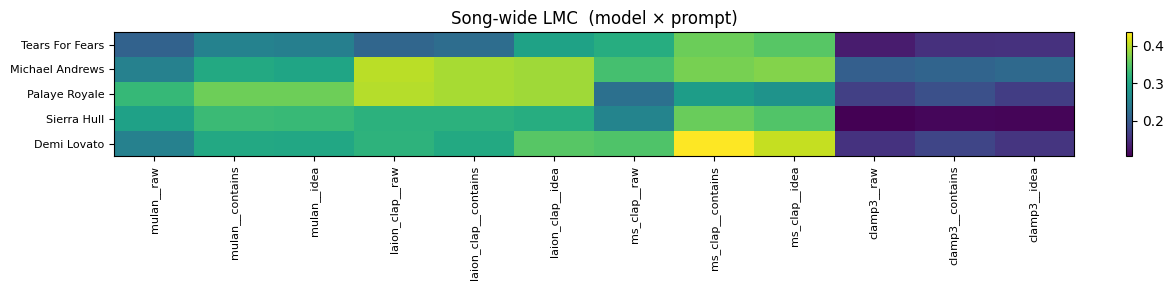

In [6]:
import matplotlib.pyplot as plt
run.plot_heatmap(out['song'], index='artist', title='Song-wide LMC  (model × prompt)')
plt.tight_layout(); plt.show()

**Rank agreement** — each metric turned into a rank (1 = most congruent). Do the metrics agree on the ordering?

In [7]:
run.rank_agreement(out['song'])

,artist,mulan__raw,mulan__contains,mulan__idea,laion_clap__raw,laion_clap__contains,laion_clap__idea,ms_clap__raw,ms_clap__contains,ms_clap__idea,clamp3__raw,clamp3__contains,clamp3__idea
0,Tears For Fears,5.0,5.0,5.0,5.0,5.0,5.0,3.0,3.0,3.0,4.0,4.0,4.0
1,Michael Andrews,3.0,3.0,4.0,1.0,2.0,1.0,2.0,2.0,2.0,1.0,1.0,1.0
2,Palaye Royale,1.0,1.0,1.0,2.0,1.0,2.0,5.0,5.0,5.0,2.0,2.0,2.0
3,Sierra Hull,2.0,2.0,2.0,4.0,3.0,4.0,4.0,4.0,4.0,5.0,5.0,5.0
4,Demi Lovato,4.0,4.0,3.0,3.0,4.0,3.0,1.0,1.0,1.0,3.0,3.0,3.0


## 4b. Segment level — chorus vs. verse
Your earlier tests suggested congruence behaves differently in the chorus vs. the verse; here it is per cover.

In [8]:
seg = out['segment']
cols = run.score_columns()
seg.pivot_table(index='artist', columns='segment_label', values=cols, aggfunc='mean').round(3)

clamp3__contains        clamp3__idea        clamp3__raw  \
segment_label             chorus  verse       chorus  verse      chorus   
artist                                                                    
Demi Lovato                0.151  0.205        0.157  0.208       0.145   
Michael Andrews            0.249  0.203        0.258  0.220       0.238   
Palaye Royale              0.242  0.187        0.252  0.200       0.220   
Sierra Hull                0.154  0.061        0.173  0.070       0.157   
Tears For Fears            0.172  0.142        0.179  0.144       0.179   

                       laion_clap__contains        laion_clap__idea         \
segment_label    verse               chorus  verse           chorus  verse   
artist                                                                       
Demi Lovato      0.212                0.222  0.270            0.109  0.297   
Michael Andrews  0.211                0.376  0.310            0.347  0.269   
Palaye Royale    0.194                0.367  0.420            0.390  0.297   
Sierra Hull      0.091                0.234  0.269            0.208  0.272   
Tears For Fears  0.155                0.257  0.269            0.312  0.232   

                 ... ms_clap__idea        ms_clap__raw        mulan__contains  \
segment_label    ...        chorus  verse       chorus  verse          chorus   
artist           ...                                                            
Demi Lovato      ...         0.393  0.397        0.319  0.376           0.362   
Michael Andrews  ...         0.431  0.391        0.335  0.326           0.299   
Palaye Royale    ...         0.338  0.288        0.250  0.217           0.421   
Sierra Hull      ...         0.299  0.386        0.170  0.303           0.411   
Tears For Fears  ...         0.319  0.380        0.292  0.297           0.061   

                       mulan__idea        mulan__raw         
segment_label    verse      chorus  verse     chorus  verse  
artist                                                       
Demi Lovato      0.273       0.295  0.279      0.182  0.219  
Michael Andrews  0.383       0.268  0.372      0.220  0.293  
Palaye Royale    0.377       0.402  0.368      0.298  0.263  
Sierra Hull      0.311       0.394  0.296      0.377  0.257  
Tears For Fears  0.302      -0.012  0.306     -0.035  0.254  

[5 rows x 24 columns]

## 4c. Line level — most / least congruent lines
Pick any one metric column to sort by (swap `metric` below).

In [9]:
metric = 'mulan__idea'   # any of run.score_columns()
line = out['line']
line[['artist','line_index','position_pct','line_text', metric]] \
    .sort_values(metric, ascending=True).head(12)

,artist,line_index,position_pct,line_text,mulan__idea
147,Sierra Hull,42,74.40,It's a very very,0.019648
99,Palaye Royale,26,76.09,Mad world,0.048189
14,Tears For Fears,14,30.32,Mad world,0.066751
15,Tears For Fears,15,32.25,Mad world,0.076898
16,Tears For Fears,16,34.12,Mad world,0.083334
56,Michael Andrews,13,47.19,Mad world,0.084359
125,Sierra Hull,20,36.69,It's a very very,0.095473
98,Palaye Royale,25,73.34,Mad world,0.100652
130,Sierra Hull,25,58.68,Happy birthday,0.105282
70,Michael Andrews,27,89.01,Mad world,0.105565


## Notes & next steps

- CSVs are in `validation/results/`. Score columns are `<model>__<prompt>` (4×3 = 12).
- Compare **orderings**, not absolute cosines, across models (each lives in its own space).
- To widen the sweep: enable `config.OPTIONAL_PROMPTS`, or point `config.PLAYLIST_ID` at another playlist.
- To scale to the real corpus later, feed `master_results.csv` tracks through the same `models` + `run` code.
- Offline plumbing test: `python -m lmcval.selftest`.